In [36]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100 , n_features= 2 , n_informative=1, hypercube= False, class_sep=20,
                          random_state=41 , n_classes = 2 , n_clusters_per_class=1 , n_redundant=0)

In [37]:
import matplotlib.pyplot as plt 

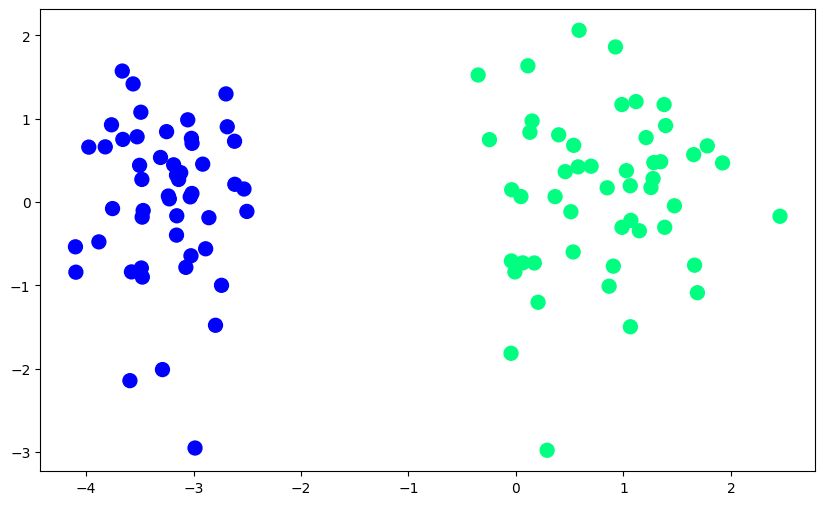

In [38]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [42]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty= None, solver='sag')
lor.fit(X,y)

/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [43]:
print(lor.coef_)
print(lor.intercept_)

[[4.89696835 0.2306284 ]]
[5.86022277]


In [44]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [45]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [71]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [77]:
def gd(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(50000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr * (np.dot((y-y_hat),X) / X.shape[1])

    return weights[1:],weights[0]

In [78]:
coef_,intercept_ = gd(X,y)

In [79]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [80]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

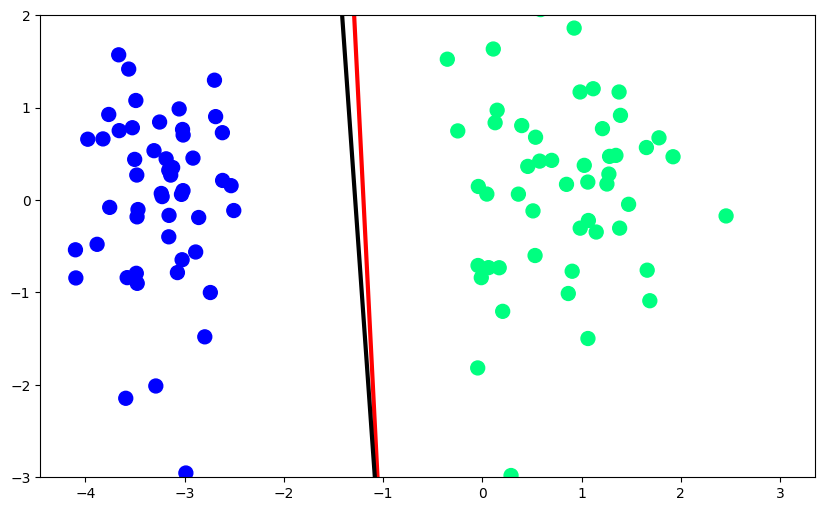

In [81]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth='3')
plt.plot(x_input1,y_input1,color='black',linewidth='3')
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)